# HYPOTHESIS 1: The gap perception between men and women is narrowing


Our hypothesis posits that the vocabulary used to describe men and women is converging, suggesting that over time, the discourse surrounding women has become increasingly similar to that of men (in terms of highlighted achievements, virtues, and social roles). To test this, we divided the dataset by year of death and fitted a year-specific TF-IDF vectorizer to create an adjusted vocabulary for each period. Subsequently, we generated two distinct centroid vectors (mean Document-Term Matrices) for men and women per year. Finally, we computed the cosine similarity between these vectors annually. This provides a longitudinal measure of the semantic proximity between gendered discourses, reflecting how society's values regarding men and women have evolved toward convergence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
import spacy
import subprocess
import sys

def install_spacy_model(model_name):
    try:
        return spacy.load(model_name)
    except OSError:
        print(f"Downloading spaCy model: {model_name}")
        subprocess.check_call([sys.executable, "-m", "spacy", "download", model_name])
        return spacy.load(model_name)

# Usas spaCy para todo el proceso de NLP (lematización, stop words, etc.)
sp = install_spacy_model('en_core_web_sm')

Last run: 2026-03-30 19:22:07


In [2]:
df = pd.read_pickle("obituaries_lemma.pkl")
df['year'] = pd.to_datetime(df['date']).dt.year

Last run: 2026-03-30 19:22:13


In [3]:
df['gender'].fillna("Unknown").value_counts()

gender
F    109758
M    105402
Name: count, dtype: int64

Last run: 2026-03-30 19:22:13


In [4]:
df['year'].fillna("Unknown").value_counts().sort_index()

year
2002     2631
2003     3648
2004     4454
2005     5909
2006     7461
2007     8863
2008     7653
2009    12083
2010    12816
2011    13181
2012    12553
2013    12282
2014    11498
2015    11731
2016    11472
2017    11006
2018     9801
2019     8921
2020     9569
2021     6253
2022     9127
2023     8033
2024     7160
2025     7055
Name: count, dtype: int64

Last run: 2026-03-30 19:22:14


Year 2002: Similarity = 0.8233, Std_M = 0.0172, Std_F = 0.0150
Year 2003: Similarity = 0.8249, Std_M = 0.0142, Std_F = 0.0124
Year 2004: Similarity = 0.8070, Std_M = 0.0131, Std_F = 0.0115
Year 2005: Similarity = 0.8081, Std_M = 0.0118, Std_F = 0.0106
Year 2006: Similarity = 0.8128, Std_M = 0.0110, Std_F = 0.0098
Year 2007: Similarity = 0.8105, Std_M = 0.0103, Std_F = 0.0092
Year 2008: Similarity = 0.8215, Std_M = 0.0105, Std_F = 0.0094
Year 2009: Similarity = 0.8354, Std_M = 0.0091, Std_F = 0.0083
Year 2010: Similarity = 0.8482, Std_M = 0.0087, Std_F = 0.0079
Year 2011: Similarity = 0.8486, Std_M = 0.0087, Std_F = 0.0079
Year 2012: Similarity = 0.8649, Std_M = 0.0087, Std_F = 0.0080
Year 2013: Similarity = 0.8672, Std_M = 0.0086, Std_F = 0.0079
Year 2014: Similarity = 0.8760, Std_M = 0.0085, Std_F = 0.0080
Year 2015: Similarity = 0.8768, Std_M = 0.0083, Std_F = 0.0077
Year 2016: Similarity = 0.8869, Std_M = 0.0083, Std_F = 0.0076
Year 2017: Similarity = 0.8717, Std_M = 0.0082, Std_F =

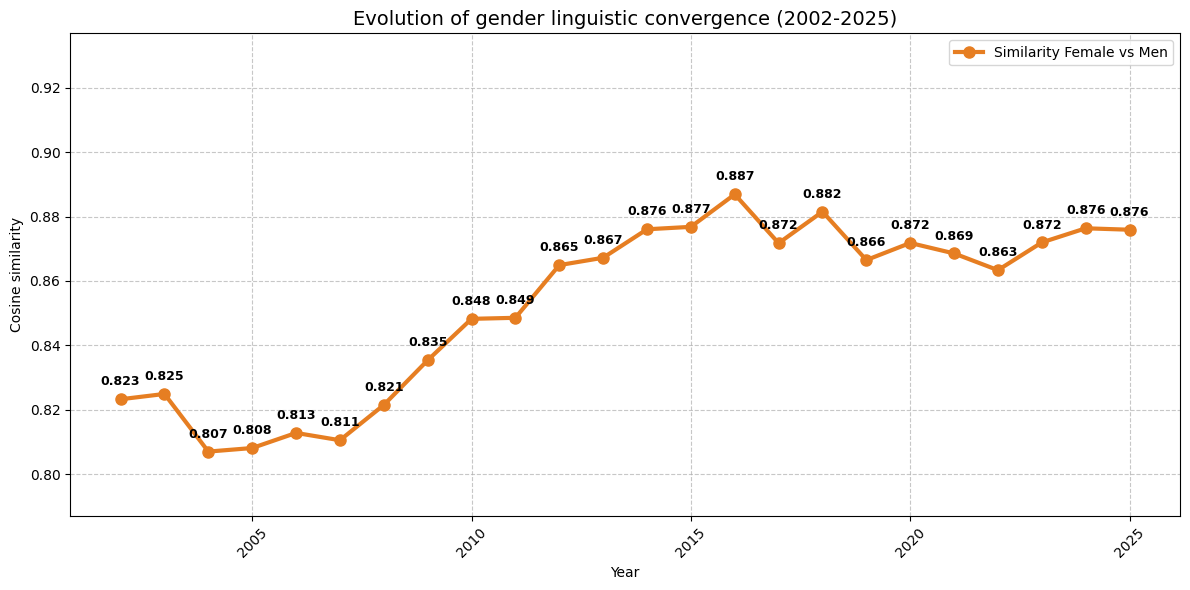

Last run: 2026-03-30 19:22:26


In [5]:
years = list(range(2002, 2026))
similarity_results = []

for i in years:
    
    df_year = df[df['year'] == i]
    text_m = df_year[df_year['gender'] == 'M']['text_clean']
    text_f = df_year[df_year['gender'] == 'F']['text_clean']
    
    if len(text_m) > 0 and len(text_f) > 0:
        # We create an specific TF-IDF for this year 
        vectorizer = TfidfVectorizer(max_df=0.4, min_df=2)
        vectorizer.fit(df_year['text_clean'])
        
        # Transform texts
        tfidf_m_matrix = vectorizer.transform(text_m)
        tfidf_f_matrix = vectorizer.transform(text_f)
        
        # Mean vectors
        tfidf_m = tfidf_m_matrix.mean(axis=0)
        tfidf_f = tfidf_f_matrix.mean(axis=0)
        
        # We compute the cosine similarity between centroids
        sim = cosine_similarity(np.asarray(tfidf_m), np.asarray(tfidf_f))[0][0]

        # Intra-group similarity: average pairwise cosine within each group
        intra_sim_m = cosine_similarity(tfidf_m_matrix).mean()
        intra_sim_f = cosine_similarity(tfidf_f_matrix).mean()
        
        similarity_results.append({
            'Year': i,
            'Similarity': sim
        })

        # Standard deviation within each gender
        std_m = tfidf_m_matrix.toarray().std(axis=0).mean()  # average std across all features
        std_f = tfidf_f_matrix.toarray().std(axis=0).mean()
        
        print(f"Year {i}: Similarity = {sim:.4f}, Std_M = {std_m:.4f}, Std_F = {std_f:.4f}")

# Ploting the results
df_res = pd.DataFrame(similarity_results)

if df_res.empty:
    print("Error: No data to plot.")
else:
    plt.figure(figsize=(12, 6))
    plt.plot(df_res['Year'], df_res['Similarity'], 
             marker='o', color='#e67e22', linewidth=3, markersize=8, label='Similarity Female vs Men')

    for i, row in df_res.iterrows():
        plt.annotate(f"{row['Similarity']:.3f}", 
                     (row['Year'], row['Similarity']), 
                     textcoords="offset points", 
                     xytext=(0,10), 
                     ha='center', 
                     fontweight='bold',
                     fontsize=9)

    plt.title('Evolution of gender linguistic convergence (2002-2025)', fontsize=14)
    plt.ylabel('Cosine similarity')
    plt.xlabel('Year')
    

    plt.ylim(df_res['Similarity'].min() - 0.02, df_res['Similarity'].max() + 0.05)
    
    plt.xticks(rotation=45) 
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

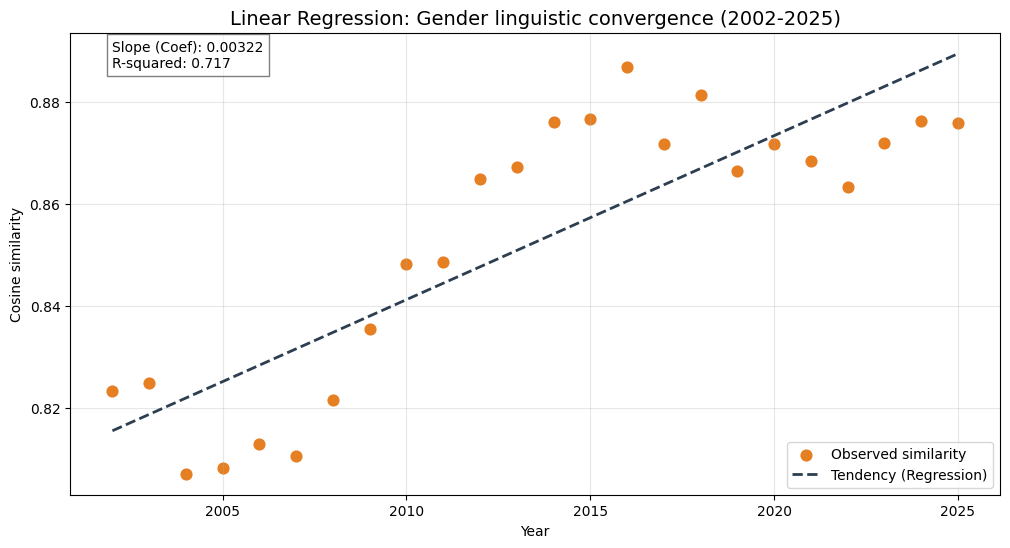

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     55.83
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.80e-07
Time:                        19:22:28   Log-Likelihood:                 68.400
No. Observations:                  24   AIC:                            -132.8
Df Residuals:                      22   BIC:                            -130.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.6329      0.868     -6.490      0.0

In [6]:
X = np.array(df_res['Year']).reshape(-1, 1).astype(float)
y = df_res['Similarity'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
X_stat = sm.add_constant(X) 
model_stat = sm.OLS(y, X_stat).fit()

# Plotting the results
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='#e67e22', label='Observed similarity', s=60)
plt.plot(X, y_pred, color='#2c3e50', linestyle='--', linewidth=2, label='Tendency (Regression)')

plt.title('Linear Regression: Gender linguistic convergence (2002-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Cosine similarity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.text(X.min(), y.max(), f"Slope (Coef): {model.coef_[0]:.5f}\nR-squared: {model_stat.rsquared:.3f}", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.savefig('paper/similarity_regression.png', dpi=300, bbox_inches='tight')
# Show the statistical summary
plt.show()
print(model_stat.summary())

# HYPOTHESIS 2: The convergence of the perception gap between men and women is driven by the topics of Profession and Family.

To identify the specific areas driving this trend, we will analyze the convergence across four distinct thematic categories: Family, Professional, Religion, and Lifestyle. By constructing specialized lexicons for each domain, we aim to determine which of these dimensions show the highest rate of linguistic assimilation and which ones remain gender-segregated.

In [7]:
themes = {
    'Religion': set([
        'church', 'faith', 'god', 'jesus', 'christ', 'lord', 'pastor', 'reverend', 
        'priest', 'bible', 'scripture', 'catholic', 'baptist', 'methodist', 
        'christian', 'faithfully', 'heaven', 'blessed', 'prayer', 'pray', 
        'ministry', 'choir', 'spirit', 'spiritual', 'soul', 'devout', 'parish',
        'mass', 'vatican', 'amen', 'worship', 'congregation', 'clerical'
    ]),
    'Profession': set([
        'career', 'retired', 'worked', 'employed', 'professor', 'teacher', 
        'engineer', 'manager', 'director', 'business', 'company', 'university', 
        'degree', 'graduate', 'college', 'professional', 'owner', 'founder', 
        'department', 'industry', 'office', 'corporation', 'executive', 'nurse',
        'doctor', 'military', 'veteran', 'served', 'army', 'navy', 'position', 
        'engineer', 'management', 'job', 'electrician', 'employee','accountant',
        'consultant', 'officer', 'recruiter', 'administrator', 'vice president','supervisor'
    ]),
    'Family': set([
        'family', 'mother', 'father', 'son', 'daughter', 'brother', 'sister',
        'grandchild', 'grandchildren', 'grandson', 'granddaughter', 'grandmother',
        'grandfather', 'nana', 'papa', 'niece', 'nephew', 'cousin', 'aunt', 'uncle',
        'husband', 'wife', 'spouse', 'partner', 'loving', 'beloved', 'devoted',
        'survived', 'children','parent'
    ]),
    'Lifestyle': set([
        'travel', 'traveled', 'journey', 'adventure', 'hiking', 'sailing', 'golf', 
        'gardening', 'cooking', 'music', 'concerts', 'art', 'reading', 'books', 
        'nature', 'outdoors', 'animals', 'dogs', 'cats', 'pets', 'beach', 'lake',
        'traveling', 'passion', 'enjoyed', 'hobbies', 'photography', 'sports', 
        'fan', 'watching', 'food', 'wine', 'restaurant', 'club', 'fishing', 
        'camping', 'collector', 'painting', 'dance', 'dancing', 'volunteering'
    ])
}

Last run: 2026-03-30 19:22:31


In [8]:
def lemmatize_set(word_set, nlp):
    lemmatized = set()
    for word in word_set:
        doc = nlp(word)
        for token in doc:
            lemmatized.add(token.lemma_)
    return lemmatized

themes_lemma = {theme: lemmatize_set(words, sp) for theme, words in themes.items()}

Last run: 2026-03-30 19:22:32


In [9]:
tokens = set(vectorizer.get_feature_names_out())
len(tokens)

7173

Last run: 2026-03-30 19:22:32


In [10]:
# Make sure that the dictionaries we selected are part of tokens, otherwise remove those words from the themes and print words that were removed
for theme, words in themes_lemma.items():
    valid_words = set()
    print(f"Checking theme '{theme}' with {len(words)} words...")
    print(f"Remove words not in tokens:")
    for word in words:
        if word in tokens:
            valid_words.add(word)
        else:
            print(f"Removed '{word}'")
    themes_lemma[theme] = valid_words

Checking theme 'Religion' with 33 words...
Remove words not in tokens:
Removed 'jesus'
Removed 'christian'
Removed 'amen'
Removed 'christ'
Removed 'methodist'
Removed 'baptist'
Removed 'vatican'
Removed 'reverend'
Checking theme 'Profession' with 43 words...
Remove words not in tokens:
Removed 'work'
Removed 'manager'
Removed 'management'
Checking theme 'Family' with 29 words...
Remove words not in tokens:
Removed 'family'
Removed 'love'
Checking theme 'Lifestyle' with 38 words...
Remove words not in tokens:
Removed 'enjoy'
Last run: 2026-03-30 19:22:33


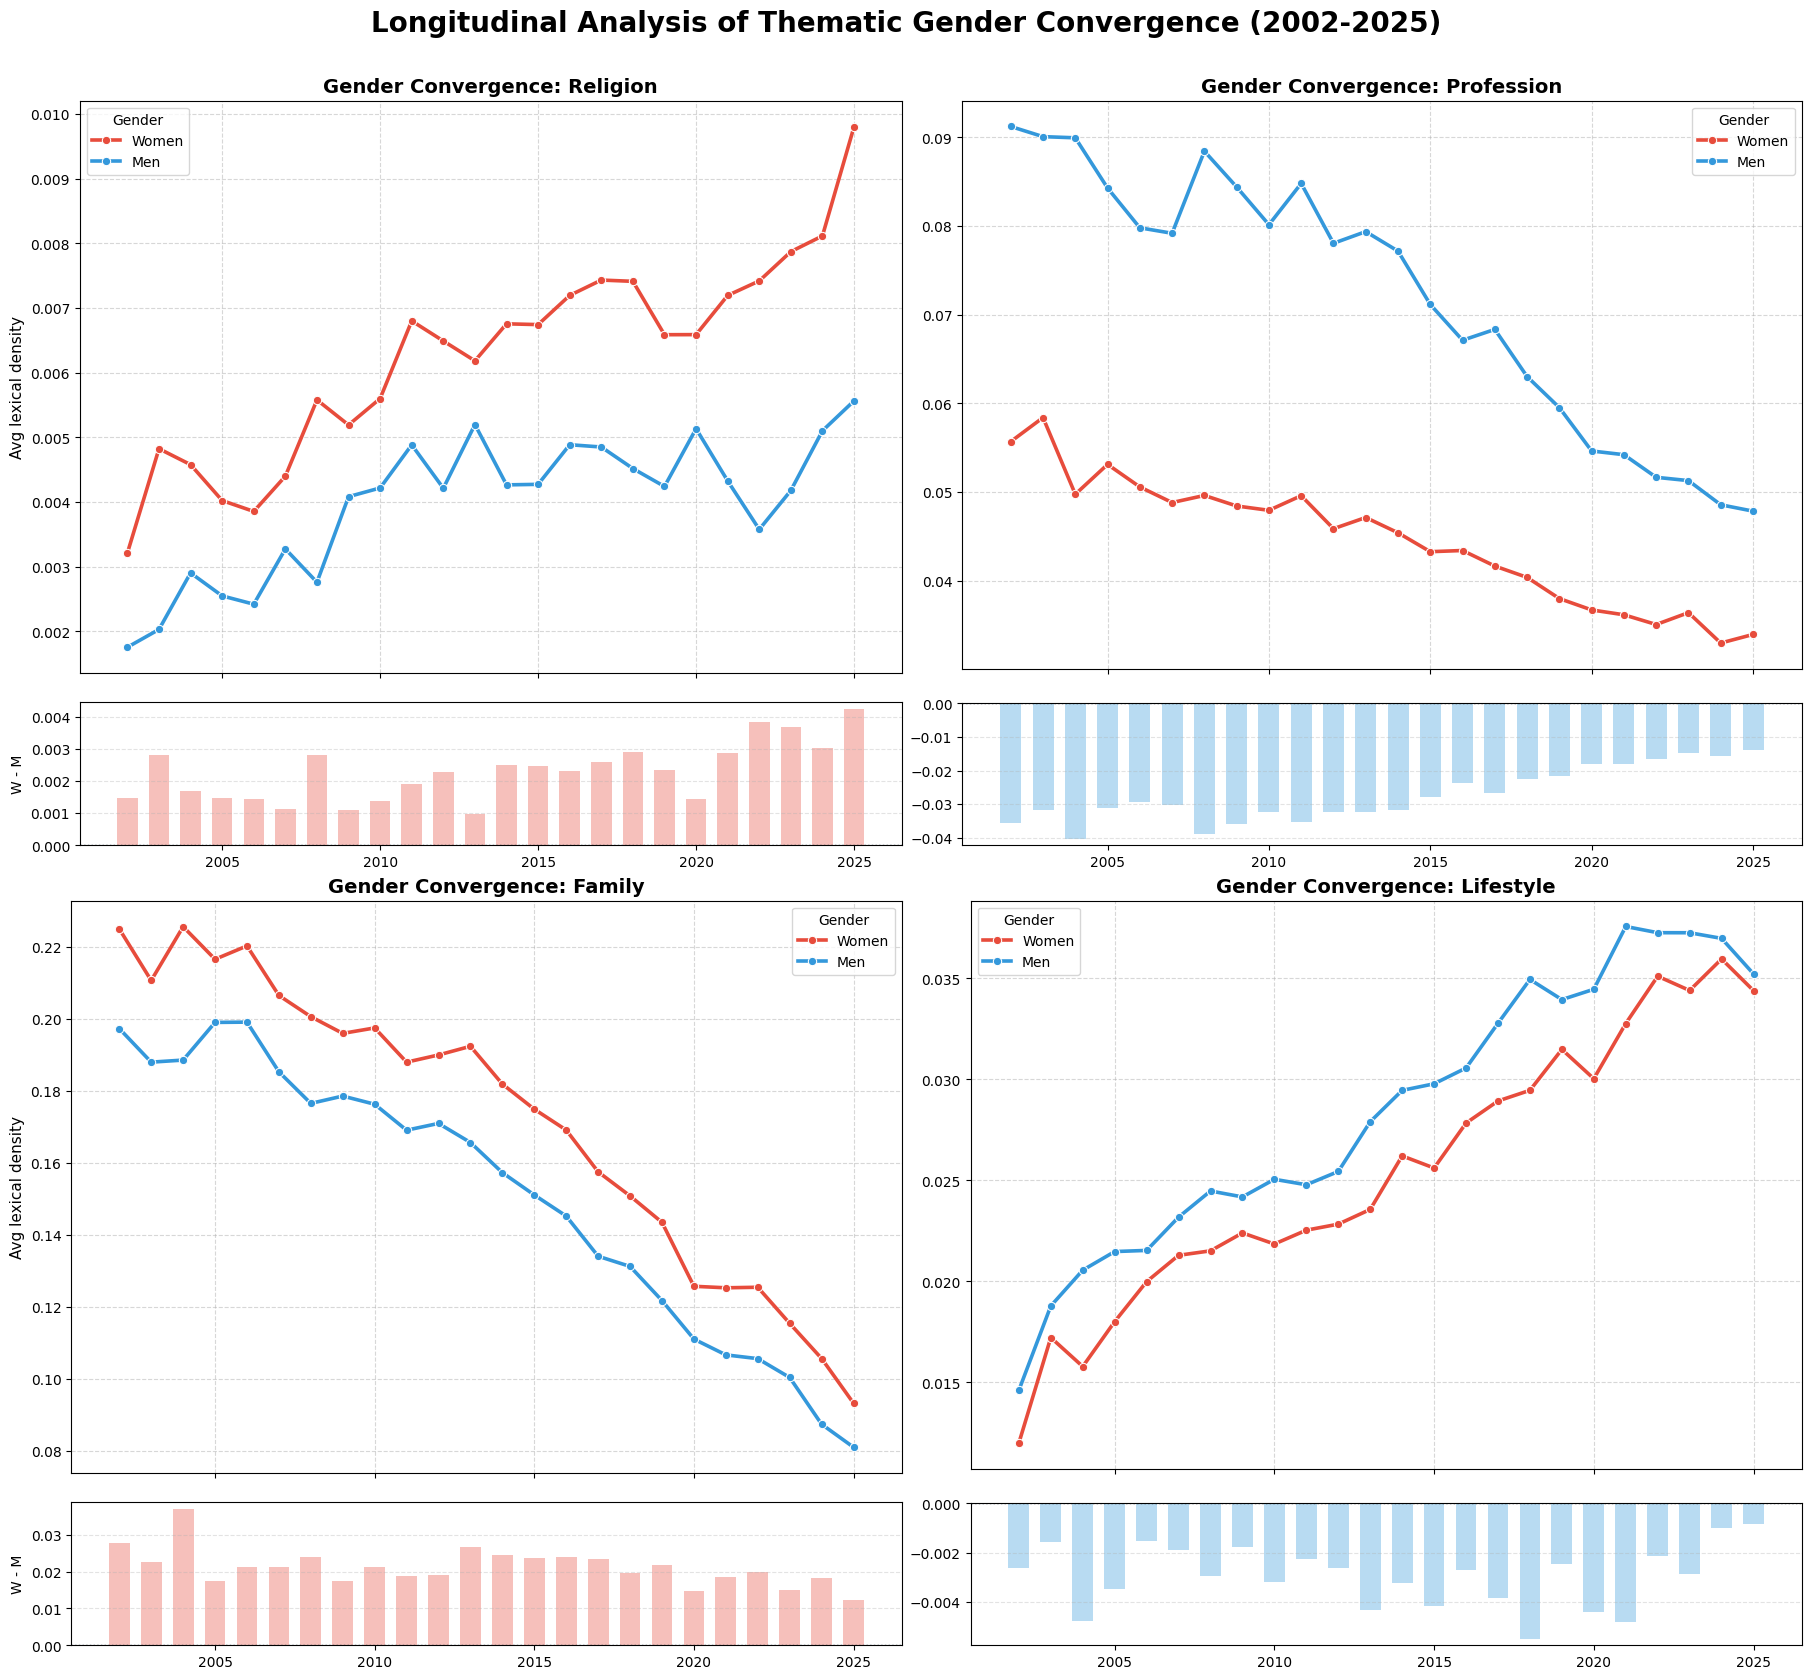

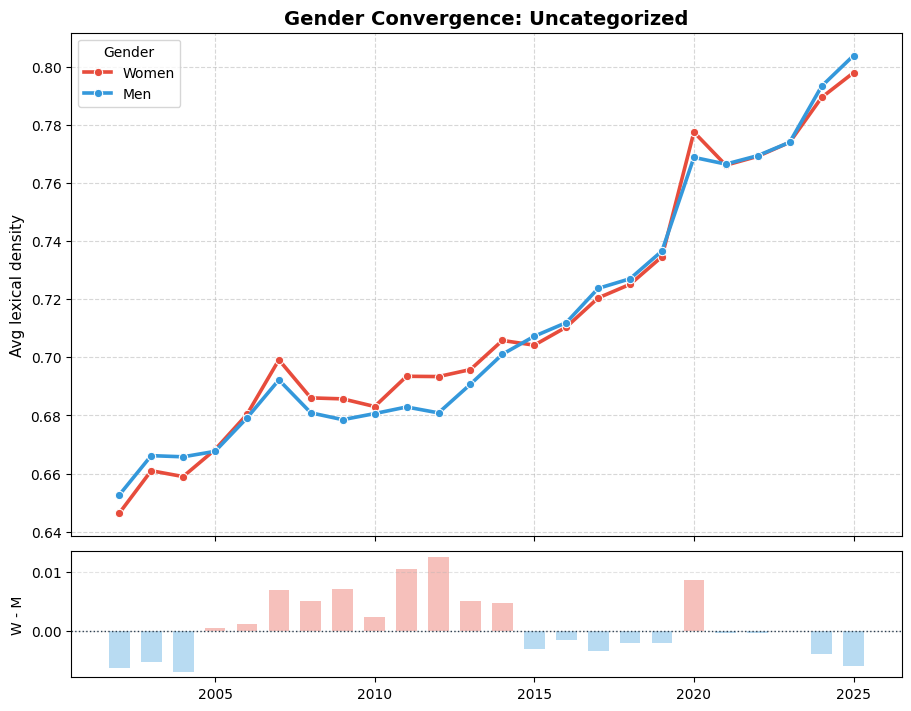

Last run: 2026-03-30 19:22:37


In [11]:
def get_density(text, word_set):
    if not isinstance(text, str):
        return 0
    tokens = text.split()
    if not tokens:
        return 0
    return sum(1 for word in tokens if word in word_set) / len(tokens)

for name, word_set in themes_lemma.items():
    df[name] = df['text_clean'].apply(lambda x: get_density(x, word_set))

# Add Uncategorized density: token share not covered by any theme lexicon.
all_theme_tokens = set().union(*themes_lemma.values())

def get_uncategorized_density(text, covered_tokens):
    if not isinstance(text, str):
        return 0
    tokens = text.split()
    if not tokens:
        return 0
    return sum(1 for word in tokens if word not in covered_tokens) / len(tokens)

df['Uncategorized'] = df['text_clean'].apply(lambda x: get_uncategorized_density(x, all_theme_tokens))

all_categories = list(themes.keys()) + ['Uncategorized']
evolution = df.groupby(['year', 'gender'])[all_categories].mean().reset_index()
evolution['gender_label'] = evolution['gender'].map({'M': 'Men', 'F': 'Women'})
gender_colors = {'Men': '#3498db', 'Women': '#e74c3c'}

# Main 2x2 panel for core themes.
main_categories = list(themes.keys())
fig = plt.figure(figsize=(18, 16), constrained_layout=True)
outer = fig.add_gridspec(2, 2, wspace=0.18, hspace=0.14)

for i, cat in enumerate(main_categories):
    row, col = divmod(i, 2)
    inner = outer[row, col].subgridspec(2, 1, height_ratios=[4, 1], hspace=0.03)

    ax_main = fig.add_subplot(inner[0])
    ax_diff = fig.add_subplot(inner[1], sharex=ax_main)

    sns.lineplot(
        data=evolution,
        x='year',
        y=cat,
        hue='gender_label',
        ax=ax_main,
        palette=gender_colors,
        linewidth=2.6,
        marker='o',
        markersize=6
    )

    cat_wide = evolution.pivot(index='year', columns='gender_label', values=cat).sort_index()
    if {'Women', 'Men'}.issubset(cat_wide.columns):
        diff = cat_wide['Women'] - cat_wide['Men']
        bar_colors = np.where(diff >= 0, '#e74c3c', '#3498db')
        ax_diff.bar(cat_wide.index, diff, width=0.65, color=bar_colors, alpha=0.35)
        ax_diff.axhline(0, color='#2c3e50', linestyle=':', linewidth=1)

    ax_main.set_title(f'Gender Convergence: {cat}', fontsize=14, fontweight='bold')
    if col == 0:
        ax_main.set_ylabel('Avg lexical density', fontsize=11)
        ax_diff.set_ylabel('W - M', fontsize=10)
    else:
        ax_main.set_ylabel('')
        ax_diff.set_ylabel('')

    ax_main.set_xlabel('')
    ax_diff.set_xlabel('')
    ax_main.grid(True, linestyle='--', alpha=0.5)
    ax_main.legend(title='Gender', loc='best')
    ax_main.tick_params(axis='x', labelbottom=False)
    ax_diff.grid(True, axis='y', linestyle='--', alpha=0.35)

fig.suptitle('Longitudinal Analysis of Thematic Gender Convergence (2002-2025)',
             fontsize=20, fontweight='bold', y=1.04)
plt.savefig('paper/thematic_convergence.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
plt.show()

# Separate plot for Uncategorized only.
cat = 'Uncategorized'
fig_u = plt.figure(figsize=(9, 7), constrained_layout=True)
inner_u = fig_u.add_gridspec(2, 1, height_ratios=[4, 1], hspace=0.03)
ax_main_u = fig_u.add_subplot(inner_u[0])
ax_diff_u = fig_u.add_subplot(inner_u[1], sharex=ax_main_u)

sns.lineplot(
    data=evolution,
    x='year',
    y=cat,
    hue='gender_label',
    ax=ax_main_u,
    palette=gender_colors,
    linewidth=2.6,
    marker='o',
    markersize=6
)

cat_wide_u = evolution.pivot(index='year', columns='gender_label', values=cat).sort_index()
if {'Women', 'Men'}.issubset(cat_wide_u.columns):
    diff_u = cat_wide_u['Women'] - cat_wide_u['Men']
    bar_colors_u = np.where(diff_u >= 0, '#e74c3c', '#3498db')
    ax_diff_u.bar(cat_wide_u.index, diff_u, width=0.65, color=bar_colors_u, alpha=0.35)
    ax_diff_u.axhline(0, color='#2c3e50', linestyle=':', linewidth=1)

ax_main_u.set_title('Gender Convergence: Uncategorized', fontsize=14, fontweight='bold')
ax_main_u.set_ylabel('Avg lexical density', fontsize=11)
ax_diff_u.set_ylabel('W - M', fontsize=10)
ax_main_u.set_xlabel('')
ax_diff_u.set_xlabel('')
ax_main_u.grid(True, linestyle='--', alpha=0.5)
ax_main_u.legend(title='Gender', loc='best')
ax_main_u.tick_params(axis='x', labelbottom=False)
ax_diff_u.grid(True, axis='y', linestyle='--', alpha=0.35)

plt.savefig('paper/uncategorized_convergence.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
plt.show()

To empirically test the longitudinal evolution of the gender gap in the usage of specific thematic categories (Professional and Family, as are the ones that show the same pattern of convergence), we estimate a multiple linear regression model using Ordinary Least Squares (OLS). The objective of this specification is not merely to observe the isolated effects of gender and time, but to analyze their interaction in order to quantify how the lexical divergence between men and women has shifted over the 2002–2025 period. The fundamental equation of the model is specified as follows:

$$Y_i = \beta_0 + \beta_1 \mathit{Female}_i + \sum_{t=2003}^{2025} \gamma_t \mathit{Year}_{it} + \sum_{t=2003}^{2025} \delta_t (\mathit{Female}_i \times \mathit{Year}_{it}) + \epsilon_i$$

Where the parameters and variables are defined as:

- $Y_i$: The continuous dependent variable, representing the lexical density of a specific topic (i.e., the percentage of words associated with Professional or Family) in document $i$.

- $\mathit{Female}_i$: A binary (dummy) variable that takes the value of $1$ if the subject of document $i$ is female, and $0$ if male.

- $\mathit{Year}_{it}$: A vector of dummy variables for each year $t$ from 2003 to 2025. The year 2002 is omitted to avoid perfect multicollinearity (the dummy variable trap).

- $(\mathit{Female}_i \times \mathit{Year}_{it})$: The interaction terms between the female dummy and each specific year dummy.

- $\epsilon_i$: The idiosyncratic error term.

Whith this, the coefficients are estimates of:

- $\beta_0$ (Intercept): The expected value of the thematic density for the baseline reference group. In this design, the baseline group consists of male subjects in the starting year of the series (2002).

- $\beta_1$: Captures the difference between men and women in the baseline year (2002)

- $\gamma_t$: The main effect for each year, capturing the temporal evolution of the topic exclusively for the baseline group (males) relative to 2002.

- $\delta_t$ (Interaction coefficients): Measure the additional change in topic density for female texts relative to male texts in year $t$, compared to the baseline year.

This specification allows us to directly evaluate the hypothesis of thematic gender convergence. The absolute gender gap in any given year $t$ can be expressed as the sum of the baseline difference and the interaction term for that year ($\beta_1 + \delta_t$).

If historically male-dominated topics exhibit a negative baseline gap($\beta_1 < 0$), evidence of convergence would be reflected in positive and statistically significant interaction coefficients in subsequent years. Such coefficients indicate that the magnitude of the gender difference becomes progressively smaller over time ($|\beta_1 + \delta_t| < |\beta_1|$). By including these interaction terms, the model separates general time trends affecting both genders from gender-specific dynamics, allowing us to isolate the evolution of the linguistic gender gap.

In [12]:
df["gender_dummy"] = np.where(df["gender"] == "M", 0, 1)

for i in range(2003, 2026):
    df[f"{i}_dummy"] = (df["year"] == i).astype(int)
    df[f"{i}_F"] = df["gender_dummy"]*df[f"{i}_dummy"]


Last run: 2026-03-30 19:22:37


In [13]:
y = df["Profession"]
X_cols = ["gender_dummy"]
year_dummies = [f"{i}_dummy" for i in range(2003, 2026)]
X_cols.extend(year_dummies)
interaction_dummies = [f"{i}_F" for i in range(2003, 2026)]
X_cols.extend(interaction_dummies)
X = df[X_cols]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Profession   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     194.8
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:22:37   Log-Likelihood:             2.3323e+05
No. Observations:              215160   AIC:                        -4.664e+05
Df Residuals:                  215112   BIC:                        -4.659e+05
Df Model:                          47                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0912      0.002     39.362   

In [14]:
y_fam = df["Family"]
X_cols = ["gender_dummy"]
year_dummies = [f"{i}_dummy" for i in range(2003, 2026)]
X_cols.extend(year_dummies)
interaction_dummies = [f"{i}_F" for i in range(2003, 2026)]
X_cols.extend(interaction_dummies)
X = df[X_cols]

X = sm.add_constant(X)
model_fam = sm.OLS(y_fam, X).fit()

print(model_fam.summary())

                            OLS Regression Results                            
Dep. Variable:                 Family   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     197.9
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:22:37   Log-Likelihood:                 71261.
No. Observations:              215160   AIC:                        -1.424e+05
Df Residuals:                  215112   BIC:                        -1.419e+05
Df Model:                          47                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1973      0.005     40.092   

In [15]:
from pathlib import Path

paper_dir = Path("paper")
paper_dir.mkdir(exist_ok=True)

def export_ols_to_latex(results, out_file, caption, label):
    coef_table = results.summary2().tables[1].copy()
    coef_table.index.name = "Variable"

    # Use publication-friendly column labels and fixed 4-decimal formatting.
    coef_table = coef_table.rename(
        columns={
            "Coef.": "Coefficient",
            "Std.Err.": "Std. Error",
            "P>|t|": "p-value",
            "[0.025": "CI 2.5%",
            "0.975]": "CI 97.5%"
        }
    )

    latex_table = coef_table.to_latex(
        longtable=True,
        float_format=lambda x: f"{x:.4f}",
        caption=caption,
        label=label,
        escape=True
    )

    out_file.write_text(latex_table, encoding="utf-8")

export_ols_to_latex(
    model,
    paper_dir / "appendix_profession_ols.tex",
    "Full OLS results for Profession topic density",
    "tab:appendix_ols_profession"
)

export_ols_to_latex(
    model_fam,
    paper_dir / "appendix_family_ols.tex",
    "Full OLS results for Family topic density",
    "tab:appendix_ols_family"
 )

print("LaTeX tables written to paper/appendix_profession_ols.tex and paper/appendix_family_ols.tex")

LaTeX tables written to paper/appendix_profession_ols.tex and paper/appendix_family_ols.tex
Last run: 2026-03-30 19:22:37


# Evolution of Top Profession Words over Time

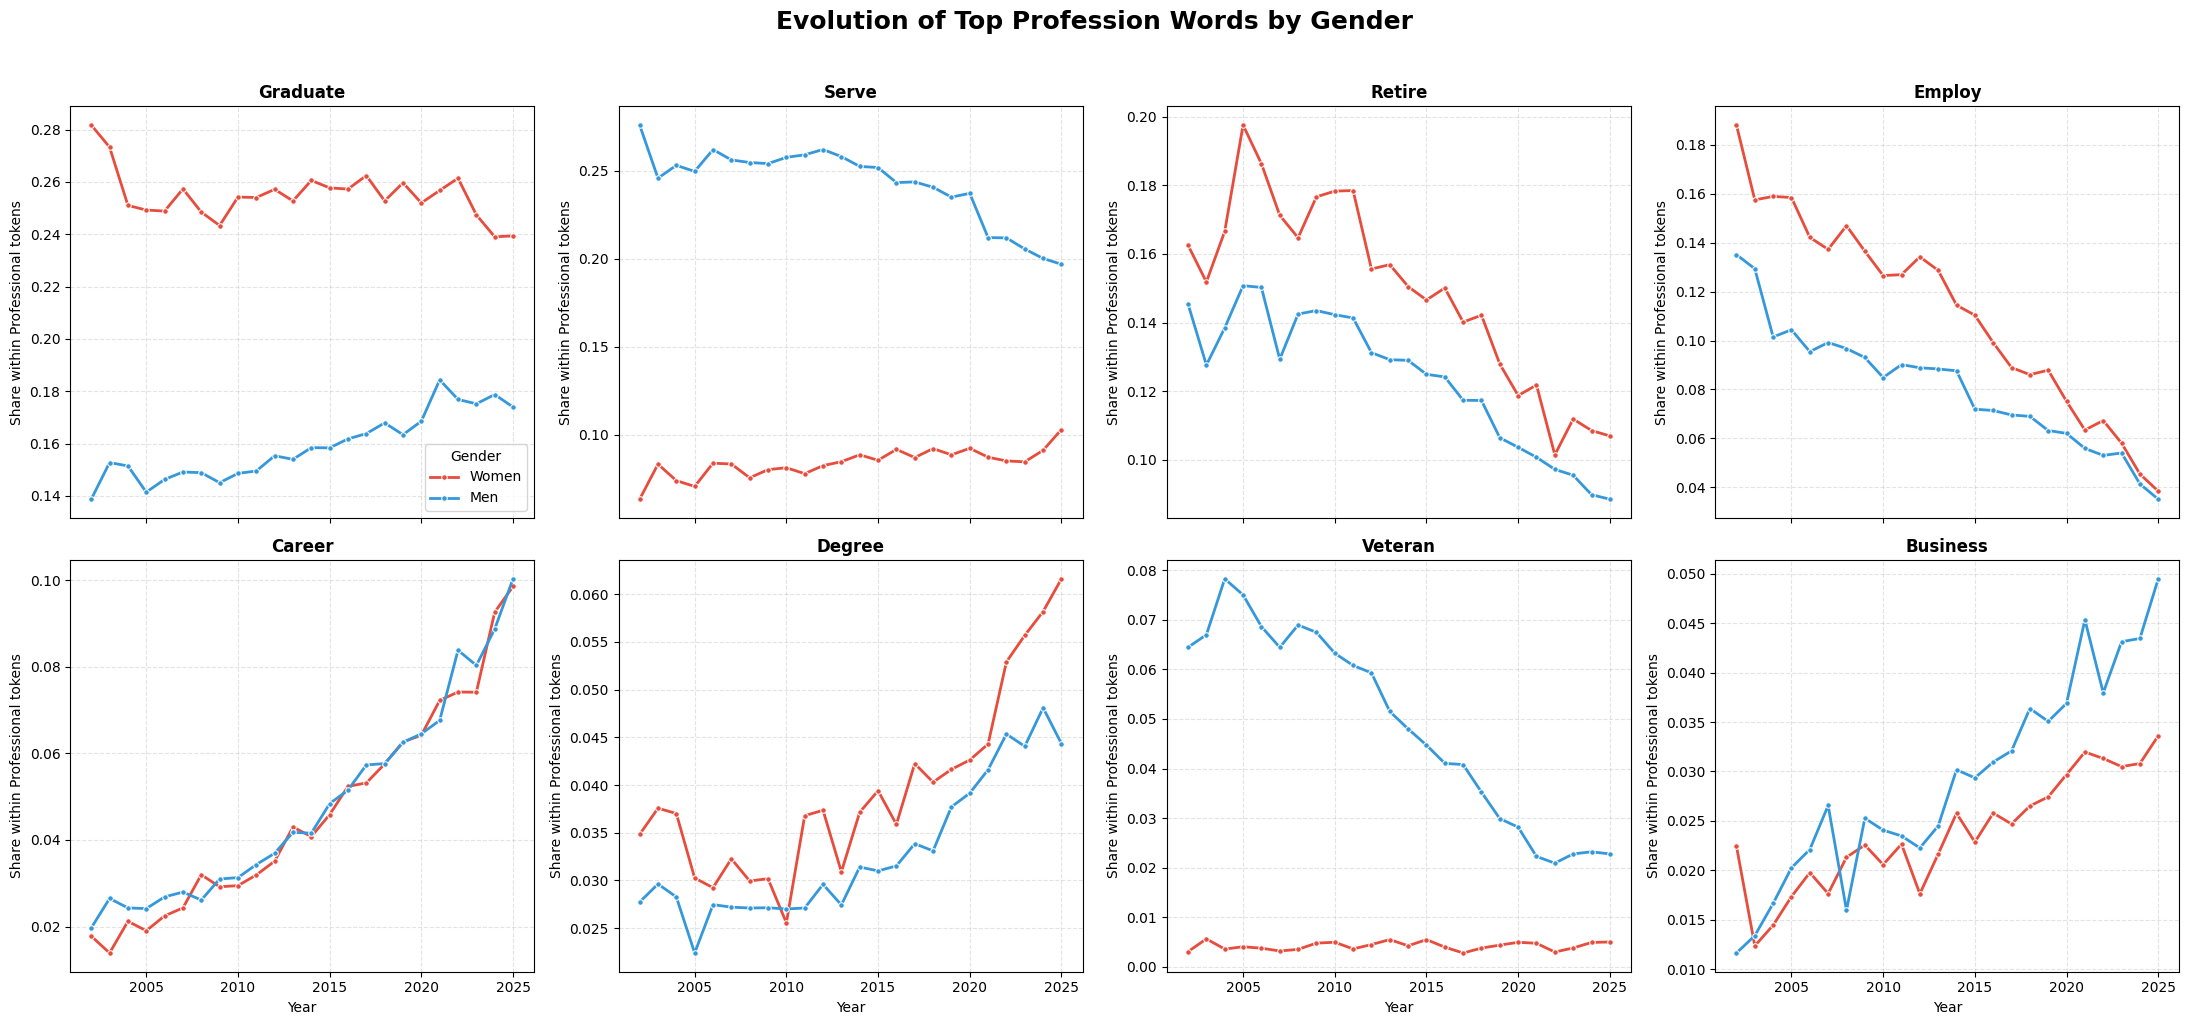

,gender,word,count
19,F,graduate,30603
33,F,retire,17705
14,F,employ,12695
34,F,serve,10310
4,F,career,5936
24,F,nurse,4905
36,F,teacher,4849
9,F,degree,4792
3,F,business,2957
6,F,company,2466


Last run: 2026-03-30 19:22:42


In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# Build a professional-only vocabulary from the lemmatized theme dictionary.
prof_vocab = sorted(themes_lemma['Profession'])

records = []
vectorizer_prof = CountVectorizer(vocabulary=prof_vocab)
years_sorted = sorted(df['year'].dropna().unique())

for year in years_sorted:
    for g in ['F', 'M']:
        texts = df.loc[(df['year'] == year) & (df['gender'] == g), 'text_clean'].fillna('')
        if texts.empty:
            continue

        X = vectorizer_prof.transform(texts)
        counts = np.asarray(X.sum(axis=0)).ravel()
        total_prof_tokens = counts.sum()

        for w, c in zip(prof_vocab, counts):
            if c > 0:
                share = (c / total_prof_tokens) if total_prof_tokens > 0 else 0
                records.append({
                    'year': year,
                    'gender': g,
                    'word': w,
                    'count': int(c),
                    'share': share
                })

prof_word_year = pd.DataFrame(records)

# Select top words by total professional counts across both genders and all years.
top_n = 8
top_words = (
    prof_word_year.groupby('word')['count']
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

plot_df = prof_word_year[prof_word_year['word'].isin(top_words)].copy()
plot_df['gender_label'] = plot_df['gender'].map({'M': 'Men', 'F': 'Women'})

fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True)
axes = axes.flatten()

for i, w in enumerate(top_words):
    ax = axes[i]
    word_df = plot_df[plot_df['word'] == w]

    sns.lineplot(
        data=word_df,
        x='year',
        y='share',
        hue='gender_label',
        ax=ax,
        palette={'Men': '#3498db', 'Women': '#e74c3c'},
        marker='o',
        linewidth=2,
        markersize=4
    )

    ax.set_title(w.capitalize(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Share within Professional tokens')
    ax.set_xlabel('Year')
    ax.grid(True, linestyle='--', alpha=0.35)

    if i != 0:
        ax.legend_.remove()

if len(top_words) > 0:
    axes[0].legend(title='Gender', loc='best')

plt.suptitle('Evolution of Top Profession Words by Gender', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('paper/professional_top_words_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

display(
    prof_word_year.groupby(['gender', 'word'])['count']
    .sum()
    .reset_index()
    .sort_values(['gender', 'count'], ascending=[True, False])
    .groupby('gender')
    .head(10)
)

## Evolution of Top Family Words by Gender

This section tracks how the most common Family-topic words evolve over time for Men and Women to assess convergence patterns.

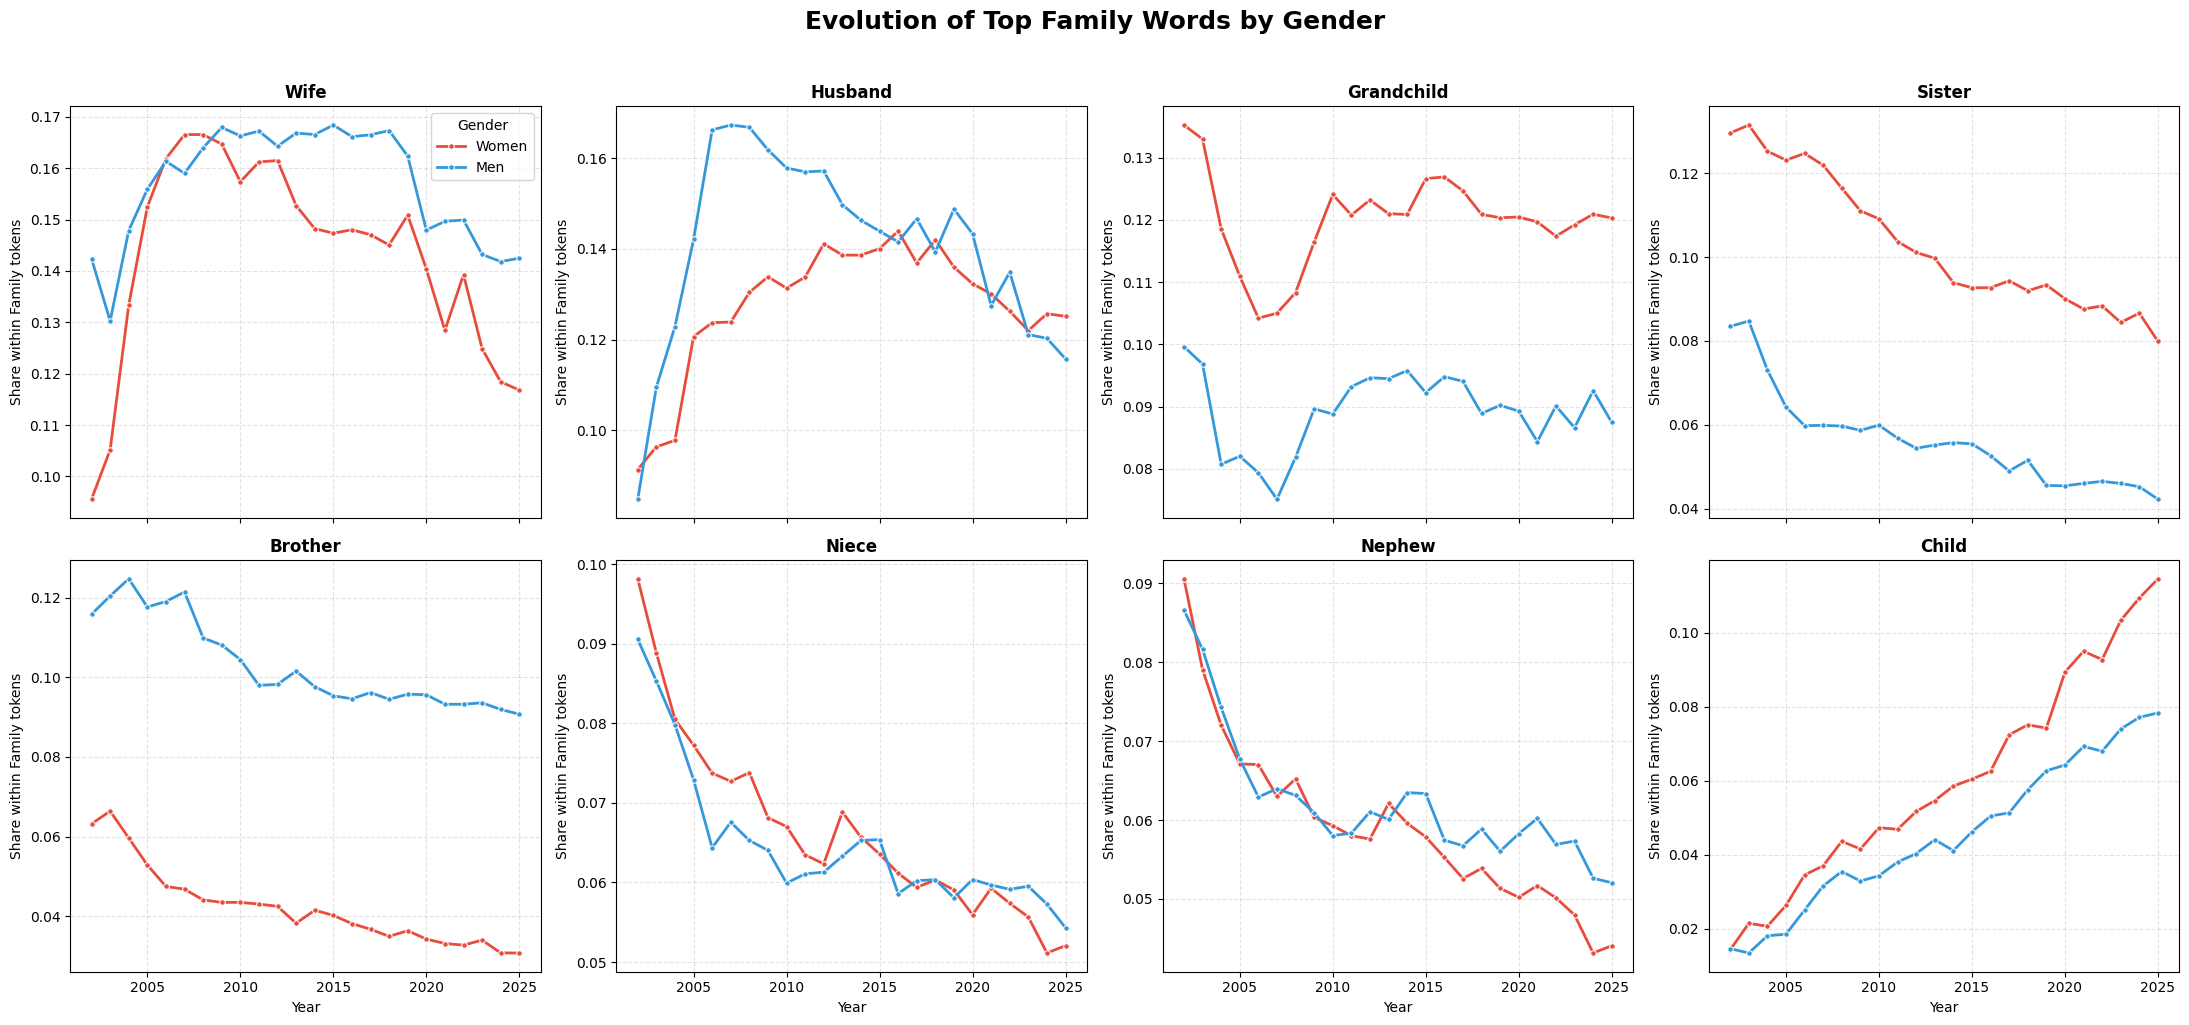

,gender,word,count
26,F,wife,63256
13,F,husband,56500
8,F,grandchild,51494
21,F,sister,43198
17,F,niece,27681
14,F,mother,27312
3,F,child,26858
16,F,nephew,24647
5,F,daughter,22811
22,F,son,19668


Last run: 2026-03-30 19:22:44


In [17]:
# Build a family-only vocabulary from the lemmatized theme dictionary.
family_vocab = sorted(themes_lemma['Family'])

family_records = []
vectorizer_family = CountVectorizer(vocabulary=family_vocab)

for year in years_sorted:
    for g in ['F', 'M']:
        texts = df.loc[(df['year'] == year) & (df['gender'] == g), 'text_clean'].fillna('')
        if texts.empty:
            continue

        X = vectorizer_family.transform(texts)
        counts = np.asarray(X.sum(axis=0)).ravel()
        total_family_tokens = counts.sum()

        for w, c in zip(family_vocab, counts):
            if c > 0:
                share = (c / total_family_tokens) if total_family_tokens > 0 else 0
                family_records.append({
                    'year': year,
                    'gender': g,
                    'word': w,
                    'count': int(c),
                    'share': share
                })

family_word_year = pd.DataFrame(family_records)

# Select top words by total family counts across both genders and all years.
top_n_family = 8
top_family_words = (
    family_word_year.groupby('word')['count']
    .sum()
    .sort_values(ascending=False)
    .head(top_n_family)
    .index
)

family_plot_df = family_word_year[family_word_year['word'].isin(top_family_words)].copy()
family_plot_df['gender_label'] = family_plot_df['gender'].map({'M': 'Men', 'F': 'Women'})

fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True)
axes = axes.flatten()

for i, w in enumerate(top_family_words):
    ax = axes[i]
    word_df = family_plot_df[family_plot_df['word'] == w]

    sns.lineplot(
        data=word_df,
        x='year',
        y='share',
        hue='gender_label',
        ax=ax,
        palette={'Men': '#3498db', 'Women': '#e74c3c'},
        marker='o',
        linewidth=2,
        markersize=4
    )

    ax.set_title(w.capitalize(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Share within Family tokens')
    ax.set_xlabel('Year')
    ax.grid(True, linestyle='--', alpha=0.35)

    if i != 0:
        ax.legend_.remove()

if len(top_family_words) > 0:
    axes[0].legend(title='Gender', loc='best')

plt.suptitle('Evolution of Top Family Words by Gender', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('paper/family_top_words_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

display(
    family_word_year.groupby(['gender', 'word'])['count']
    .sum()
    .reset_index()
    .sort_values(['gender', 'count'], ascending=[True, False])
    .groupby('gender')
    .head(10)
)